# 4. Brine properties

<a href="https://colab.research.google.com/github/jmoortgat/GasBrineBench/blob/main/notebooks/04_brine_properties.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


Density, osmotic coefficient, vapour-pressure ratio, apparent molar heat capacity, viscosity, density of CO2-loaded solutions and
permittivity. Osmotic coefficients, heat capacities and some vapour-pressure data are conventionally reported without a pressure; those
rows carry the flag `pressure-unstated` and are dropped by the default view, so this notebook uses the view `dfp` that keeps them
(everything else of the default exclusion still applies).

> **Running on Google Colab?** Click the badge above and run the cells; nothing needs to be installed. The first code cell detects
> Colab, clones the repository into `/content/GasBrineBench`, checks that pandas, numpy and matplotlib are present (Colab already has them)
> and changes into `notebooks/`, so everything after it works as on a local checkout. Locally the cell does nothing but confirm the layout.
> To use a fork or a branch, set `GBB_REPO_URL` and `GBB_BRANCH` before the cell runs.

In [1]:
# --- Colab / local bootstrap ---------------------------------------------------------------------------------
# On Colab this cell clones the repository and installs anything missing; on a local checkout it only confirms the layout.
# Re-running it is safe.
import os, subprocess, sys
from pathlib import Path

REPO_URL = os.environ.get("GBB_REPO_URL", "https://github.com/jmoortgat/GasBrineBench.git")
BRANCH = os.environ.get("GBB_BRANCH", "main")
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB or os.environ.get("GBB_FORCE_BOOTSTRAP"):
    REPO_DIR = Path("/content/GasBrineBench") if IN_COLAB else Path(os.environ.get("GBB_CLONE_DIR", "GasBrineBench_clone")).resolve()
    if not REPO_DIR.exists():
        print(f"cloning {REPO_URL} ({BRANCH}) into {REPO_DIR}")
        subprocess.check_call(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(REPO_DIR)])
    else:
        print(f"repository already cloned at {REPO_DIR}")
    missing = []
    for pkg, mod in [("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib")]:
        try:
            __import__(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print("pip install -q", " ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    os.chdir(REPO_DIR / "notebooks")
    print("cwd =", os.getcwd())
else:
    print("local environment: using the existing checkout")

local environment: using the existing checkout


In [2]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
HERE = pathlib.Path.cwd()
ROOT = HERE if (HERE / "gasbrinebench").exists() else HERE.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "notebooks"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import gasbrinebench as gbb
from gasbrinebench.vocab import DEFAULT_EXCLUDED_FLAGS
import gbb_viz as V
V.style()
# default view (what a benchmark user scores) and the view that also keeps rows without a stated pressure
df = gbb.load()
dfp = gbb.load(exclude_flags=tuple(f for f in DEFAULT_EXCLUDED_FLAGS if f != "pressure-unstated"))
dfall = gbb.load(exclude_tags=None, exclude_flags=None)
print(f"{len(dfall):,} rows in total, {len(df):,} in the default view, gasbrinebench {gbb.__version__}")

27,025 rows in total, 23,300 in the default view, gasbrinebench 1.2.0


## Density of salt solutions

(a) NaCl: density against temperature, one colour/marker per molality bin (pressure up to 100 bar so that the pressure effect stays small);
(b) NaCl near 1 mol/kg: density against pressure, by temperature bin; (c) other salts at their commonest molalities.

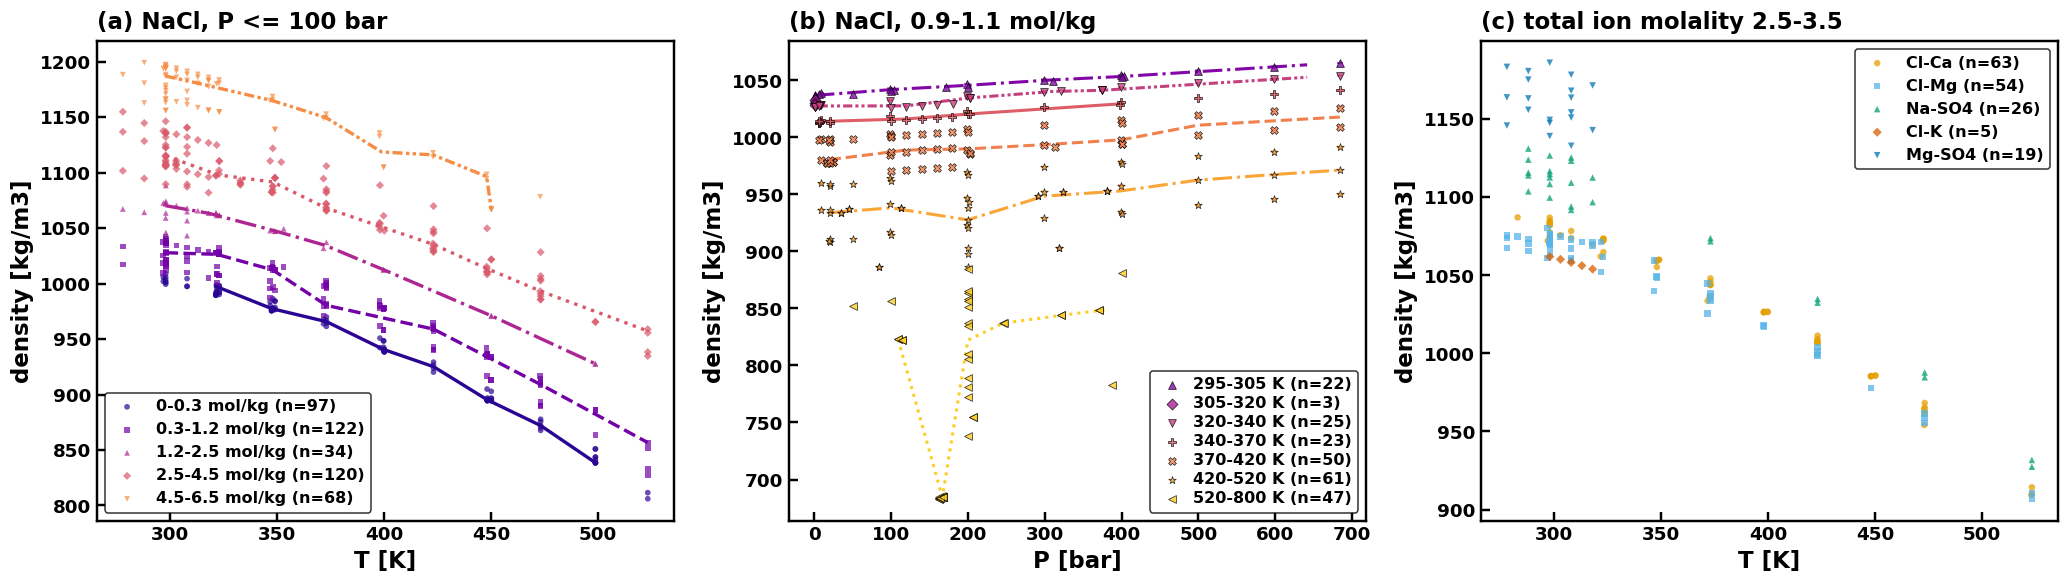

In [3]:
rho = df[df.property == "rho"]
nacl = rho[rho.salt_system.eq("Na-Cl")].copy(); nacl["m"] = nacl.m_Na
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
edges = [0, 0.3, 1.2, 2.5, 4.5, 6.5, 9]
g = nacl[nacl.P_bar <= 100]
cols = V.tbin_colors(len(edges) - 1)
for b in range(len(edges) - 1):
    w = g[g.m.between(edges[b], edges[b + 1], inclusive="left")]
    if len(w) < 5: continue
    axes[0].scatter(w.T_K, w.value, s=14, color=cols[b], marker=V.MARKERS[b], edgecolor="none", alpha=0.7, label=f"{edges[b]}-{edges[b+1]} mol/kg (n={len(w)})")
    tx, ty = V.trend(w.T_K, w.value, logx=False); axes[0].plot(tx, ty, color=cols[b], ls=V.LINESTYLES[b % 5])
axes[0].legend(loc="best"); V.lab(axes[0], "T [K]", "density [kg/m3]", "(a) NaCl, P <= 100 bar")
w = nacl[nacl.m.between(0.9, 1.1)]
V.isotherms(axes[1], w, x="P_bar", y="value", logx=False, logy=False, legend=True); V.lab(axes[1], "P [bar]", "density [kg/m3]", "(b) NaCl, 0.9-1.1 mol/kg")
for k, s in enumerate(["Cl-Ca", "Cl-Mg", "Na-SO4", "Cl-K", "Mg-SO4"]):
    w = rho[(rho.salt_system == s) & (rho.total_molality.between(2.5, 3.5)) & (rho.P_bar <= 100)]
    if len(w) < 4: continue
    axes[2].scatter(w.T_K, w.value, s=18, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k], edgecolor="none", alpha=0.75, label=f"{s} (n={len(w)})")
axes[2].legend(); V.lab(axes[2], "T [K]", "density [kg/m3]", "(c) total ion molality 2.5-3.5")
plt.tight_layout(); plt.show()

## Source-to-source differences in density

At fixed temperature, density against molality for single salts. The difference between sources is far smaller than the signal; the useful
view is the **departure from a smooth trend**, per source, in parts per thousand.

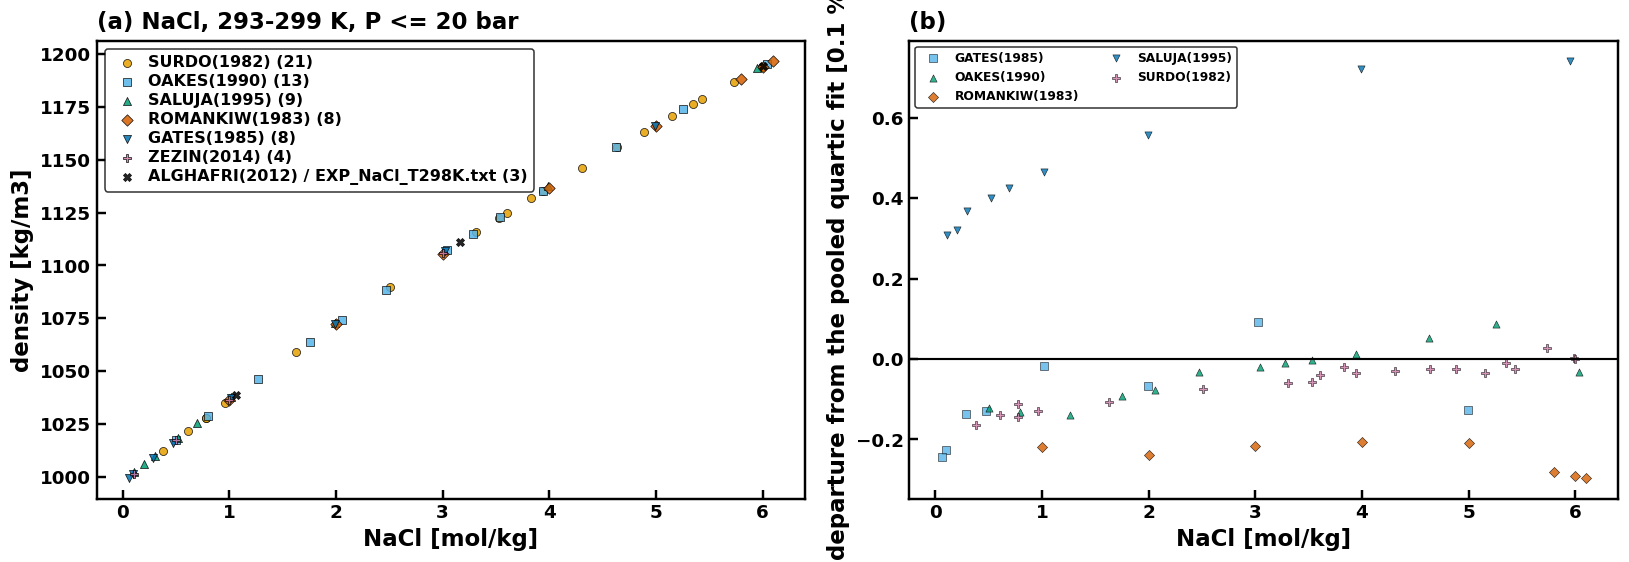

In [4]:
g = nacl[nacl.T_K.between(293, 299) & (nacl.P_bar <= 20)].dropna(subset=["m"])
fig, axes = plt.subplots(1, 2, figsize=(15, 5.3))
V.by_source(axes[0], g, x="m", y="value", top=8, logx=False, logy=False); V.lab(axes[0], "NaCl [mol/kg]", "density [kg/m3]", "(a) NaCl, 293-299 K, P <= 20 bar")
cf = np.polyfit(g.m, g.value, 4)
g = g.assign(dev=(g.value - np.polyval(cf, g.m)) / np.polyval(cf, g.m) * 1000)
for k, (s, w) in enumerate(g.groupby("source")):
    if len(w) < 5: continue
    axes[1].scatter(w.m, w.dev, s=22, color=V.WONG[(k % 6) + 1], marker=V.MARKERS[k % 12], edgecolor="black", linewidth=0.4, alpha=0.8, label=s)
axes[1].axhline(0, color="black", lw=1.4); axes[1].legend(fontsize=8, ncol=2); V.lab(axes[1], "NaCl [mol/kg]", "departure from the pooled quartic fit [0.1 %]", "(b)")
plt.tight_layout(); plt.show()

## Osmotic coefficient

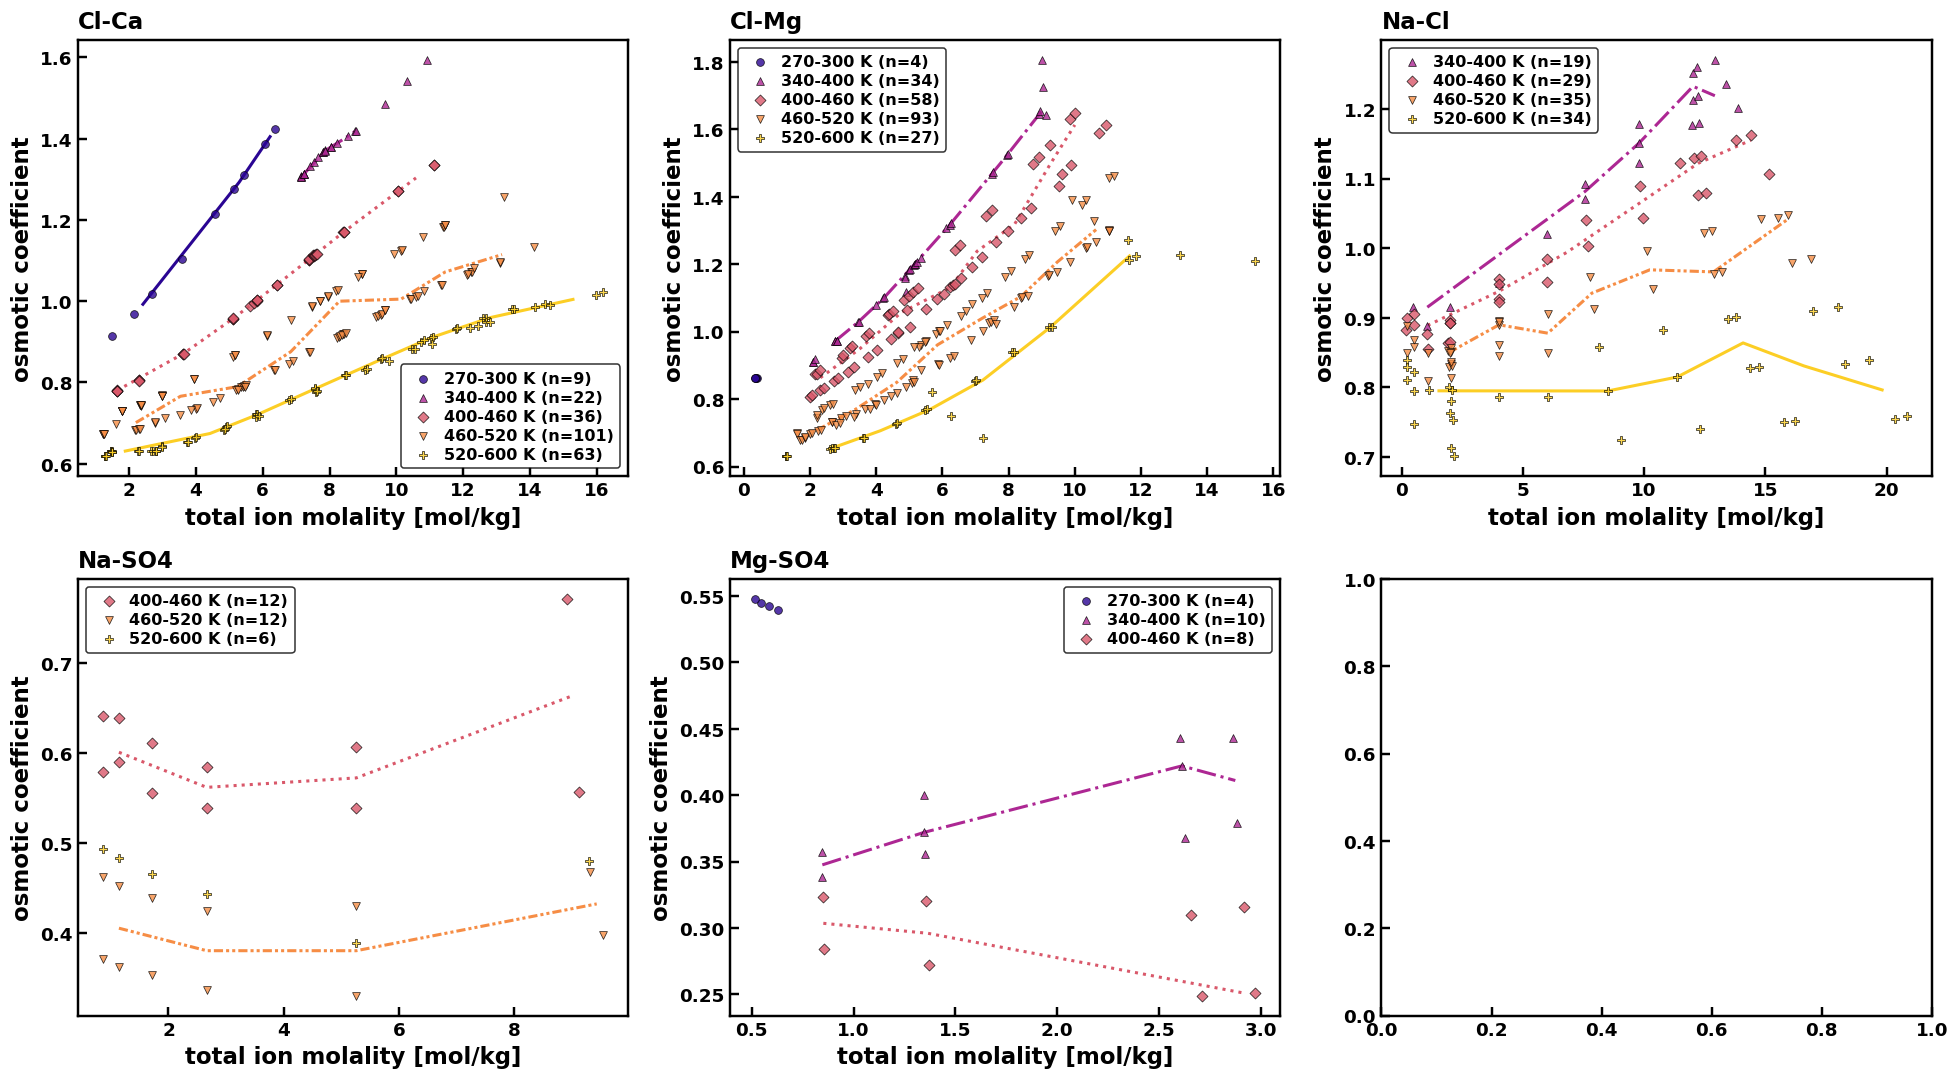

In [5]:
ph = dfp[dfp.property == "phi_osm"]
sysl = [s for s in ph.salt_system.value_counts().index if ph[ph.salt_system == s].shape[0] >= 12][:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, s in zip(axes.ravel(), sysl):
    g = ph[ph.salt_system == s].copy(); g["m"] = g.total_molality
    V.isotherms(ax, g, x="m", y="value", logx=False, logy=False, edges=[270, 300, 340, 400, 460, 520, 600])
    V.lab(ax, "total ion molality [mol/kg]", "osmotic coefficient", s)
plt.tight_layout(); plt.show()

## Vapour-pressure ratio of brines (water activity)

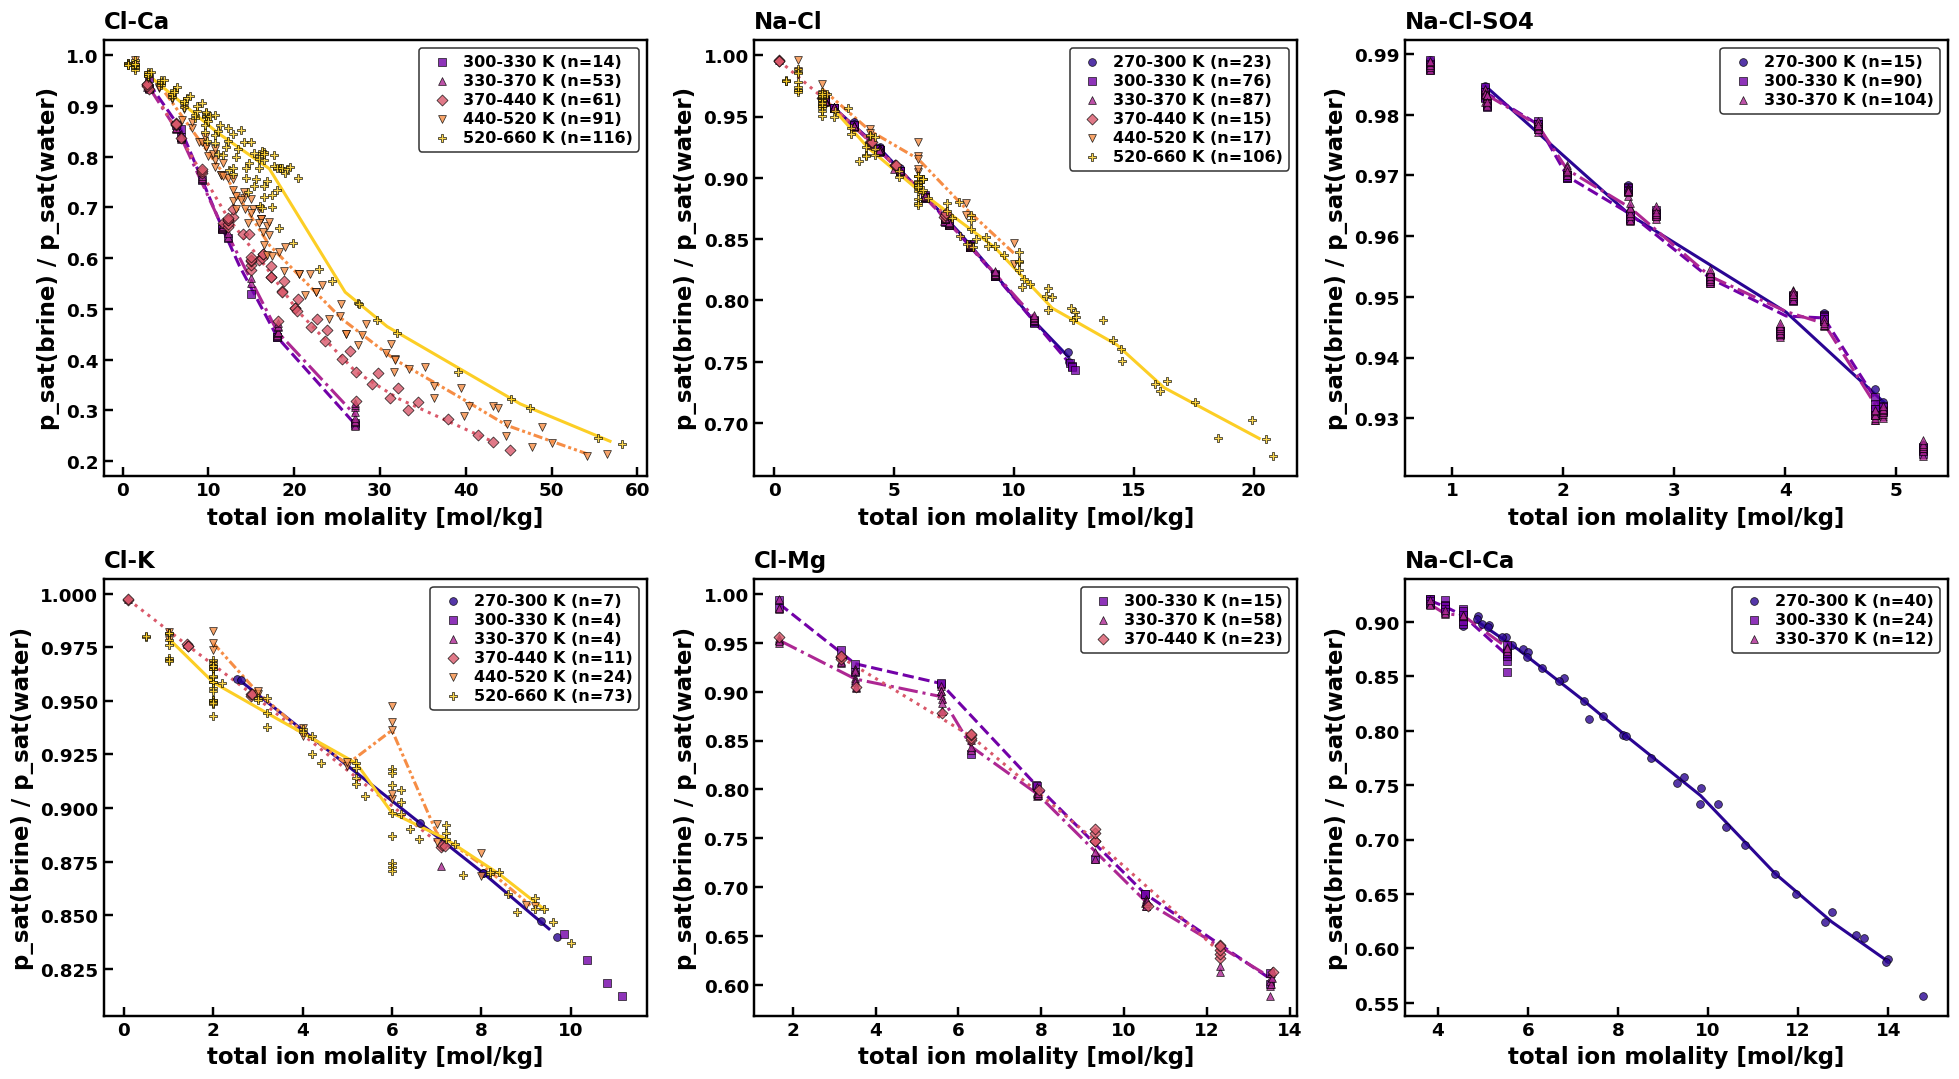

In [6]:
ps = dfp[dfp.property == "psat_ratio"]
sysl = [s for s in ps.salt_system.value_counts().index if ps[ps.salt_system == s].shape[0] >= 12][:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, s in zip(axes.ravel(), sysl):
    g = ps[ps.salt_system == s].copy(); g["m"] = g.total_molality
    V.isotherms(ax, g, x="m", y="value", logx=False, logy=False, trend_line=True, edges=[270, 300, 330, 370, 440, 520, 660])
    V.lab(ax, "total ion molality [mol/kg]", "p_sat(brine) / p_sat(water)", s)
plt.tight_layout(); plt.show()

## Apparent molar heat capacity

{'WHITE(1987)': 223, 'CALL(2000)': 216, 'PABALAN(1988)': 67, 'ROGERS(1981)': 60, 'SALUJA(1987)': 51, 'PABALAN(1988b)': 40, 'RANDALL(1929)': 19, 'PERRON(1974)': 16}


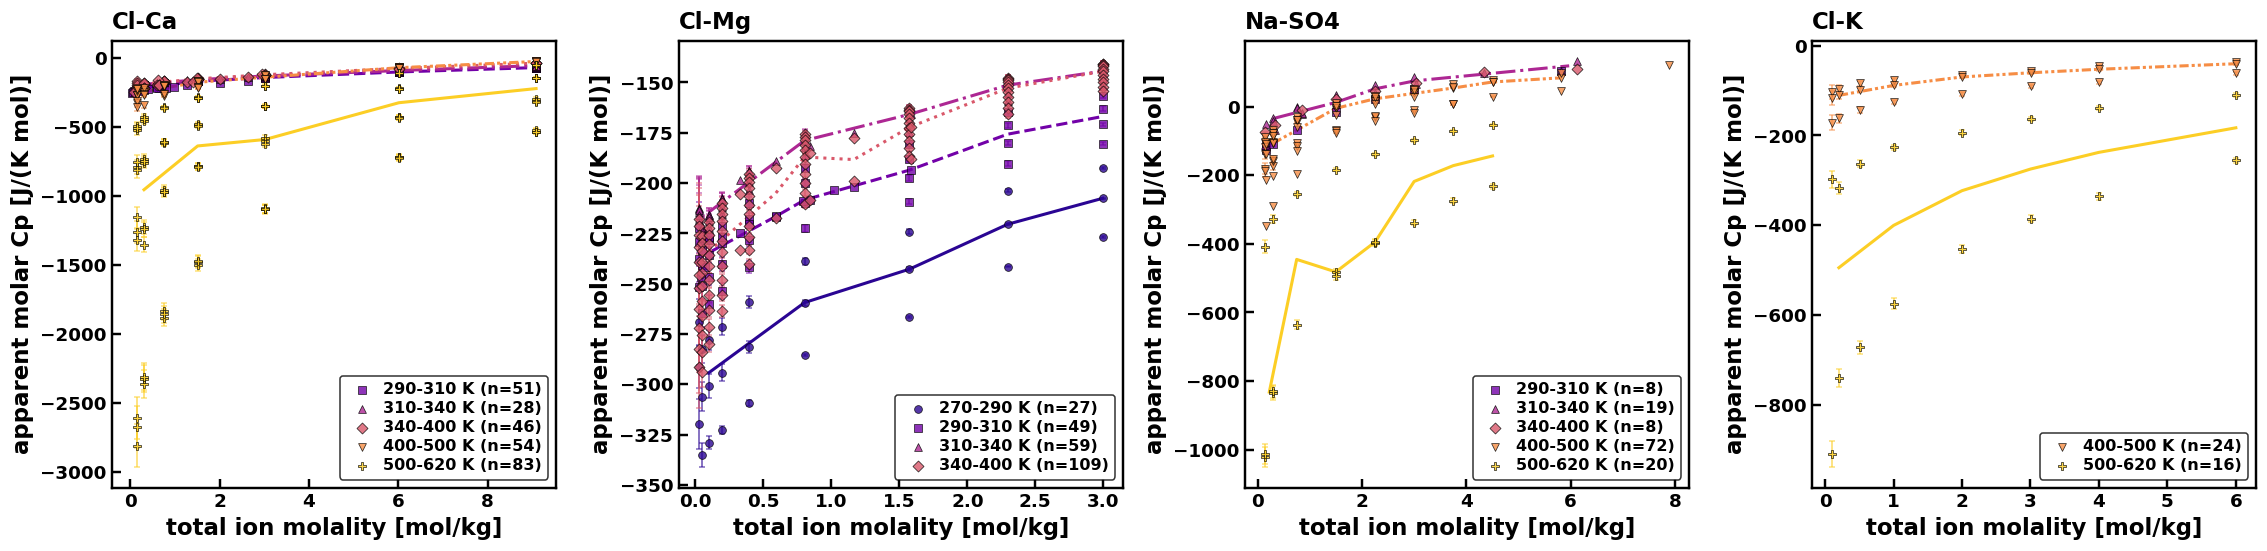

In [7]:
cp = dfp[dfp.property == "Cp_app"]
print(cp.groupby("source").size().sort_values(ascending=False).to_dict())
sysl = [s for s in cp.salt_system.value_counts().index if cp[cp.salt_system == s].shape[0] >= 10][:4]
fig, axes = plt.subplots(1, len(sysl), figsize=(5.2 * len(sysl), 5.2))
axes = np.atleast_1d(axes)
for ax, s in zip(axes, sysl):
    g = cp[cp.salt_system == s].copy(); g["m"] = g.total_molality
    V.isotherms(ax, g, x="m", y="value", logx=False, logy=False, edges=[270, 290, 310, 340, 400, 500, 620])
    V.lab(ax, "total ion molality [mol/kg]", "apparent molar Cp [J/(K mol)]", s)
plt.tight_layout(); plt.show()

## Viscosity and the density of CO2-loaded solutions

Both families carry `m_gas`, the dissolved CO2 in mol per kg of water.

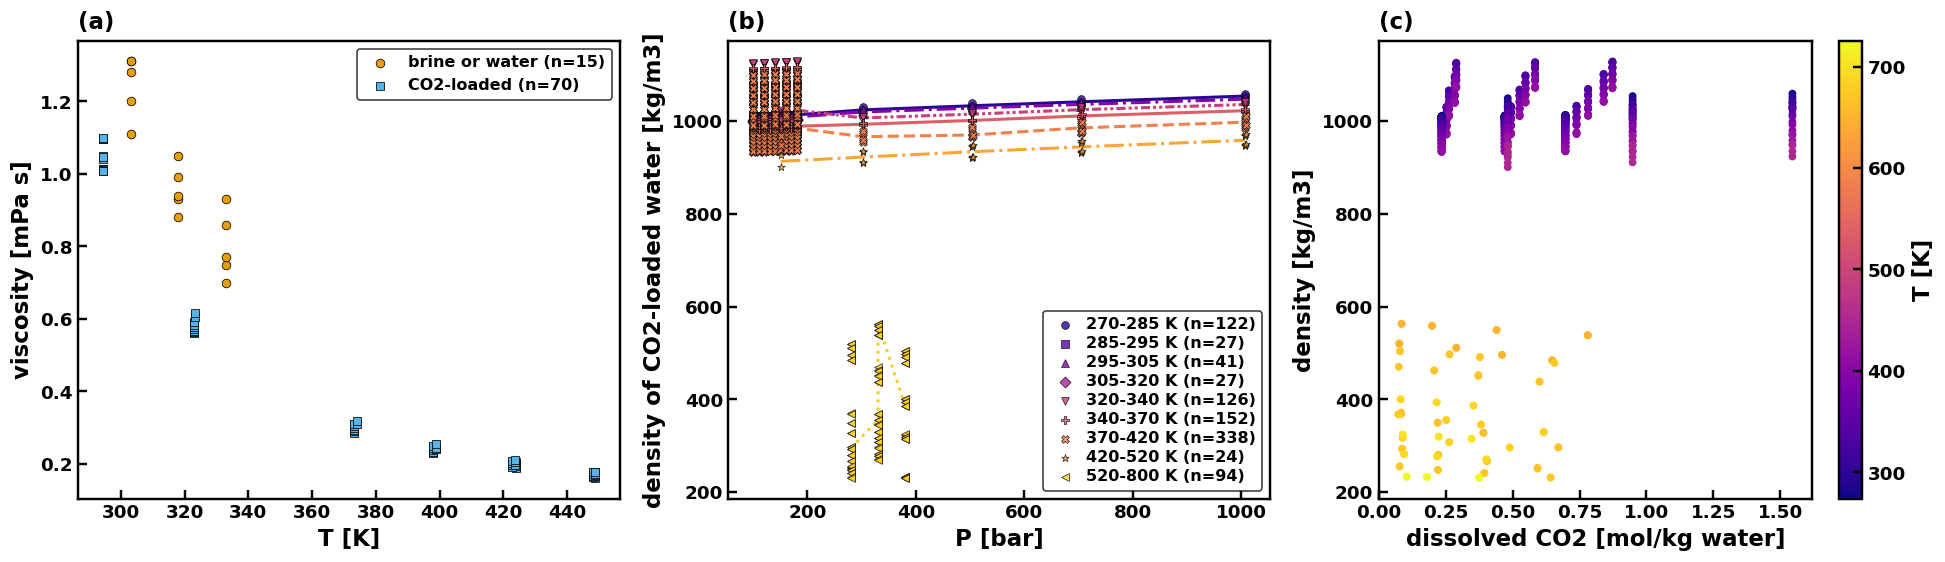

In [8]:
v = df[df.property == "visc"]; rg = df[df.property == "rho_gas_loaded"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.3))
for k, (lab_, g) in enumerate([("brine or water", v[v.gas == ""]), ("CO2-loaded", v[v.gas != ""])]):
    if len(g): axes[0].scatter(g.T_K, g.value, s=32, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k], edgecolor="black", linewidth=0.5, label=f"{lab_} (n={len(g)})")
axes[0].legend(); V.lab(axes[0], "T [K]", "viscosity [mPa s]", "(a)")
V.isotherms(axes[1], rg, x="P_bar", y="value", logx=False, logy=False); V.lab(axes[1], "P [bar]", "density of CO2-loaded water [kg/m3]", "(b)")
sc = axes[2].scatter(rg.m_gas, rg.value, c=rg.T_K, cmap="plasma", s=26, edgecolor="none"); plt.colorbar(sc, ax=axes[2], label="T [K]")
V.lab(axes[2], "dissolved CO2 [mol/kg water]", "density [kg/m3]", "(c)")
plt.tight_layout(); plt.show()

## Permittivity

`eps_r` is a low-weight extension family (13 rows, 298 K, one source).

In [9]:
display(df[df.property == "eps_r"][["source", "T_K", "P_bar", "m_Na", "m_Cl", "value", "uncertainty"]])

,source,T_K,P_bar,m_Na,m_Cl,value,uncertainty
